In [1]:
DATASET_DIR = '/kaggle/input/gan-getting-started'
WORKING_DIR = '/kaggle/working'

In [3]:
import tensorflow as tf
import os

pattern_photo_jpg = os.path.join(DATASET_DIR, 'photo_jpg', '*.jpg')
pattern_monet_jpg = os.path.join(DATASET_DIR, 'monet_jpg', '*.jpg')

list_photo_files = tf.data.Dataset.list_files([pattern_photo_jpg], shuffle=False)
list_monet_files = tf.data.Dataset.list_files([pattern_monet_jpg], shuffle=False)

print('Number of photos:', len(list_photo_files))
print('Number of Monet paintings:', len(list_monet_files))

Number of photos: 7038
Number of Monet paintings: 300


In [4]:
AUTOTUNE = tf.data.AUTOTUNE
BUFFER_SIZE = 1000
BATCH_SIZE = 4
IMG_WIDTH = 256
IMG_HEIGHT = 256

def to_m11(img):  # from [0, 1] to [-1, 1]
    img = (img * 2) - 1
    return img

def to_01(img):  # from [-1, 1] to [0, 1]
    img = (img * 0.5) + 0.5
    return img

def to_float32(img): # from [0, 255] to [0, 1]
   img = tf.image.convert_image_dtype(img, tf.float32)
   return img

def to_uint8(img): # from [0, 1] to [0, 255]
   img = tf.image.convert_image_dtype(img, tf.uint8, saturate=True)
   return img

def load_jpeg(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)    
    img = to_float32(img)
    img = tf.image.resize(img, [IMG_WIDTH, IMG_HEIGHT])
    img = to_m11(img)
    return img, file_path

loaded_photo_files = list_photo_files.map(load_jpeg, num_parallel_calls=AUTOTUNE)
loaded_monet_files = list_monet_files.map(load_jpeg, num_parallel_calls=AUTOTUNE)

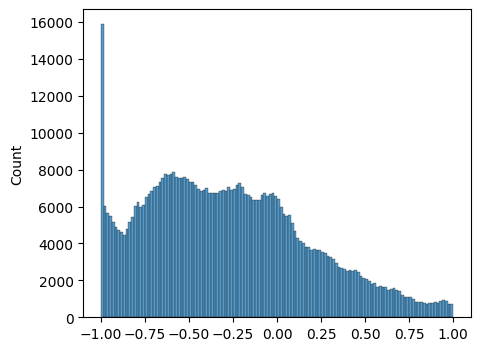

In [6]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*use_inf_as_na.*")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
image_batch, _ = next(iter(loaded_photo_files.batch(3)))
sns.histplot(tf.reshape(image_batch, [-1]))
plt.show()

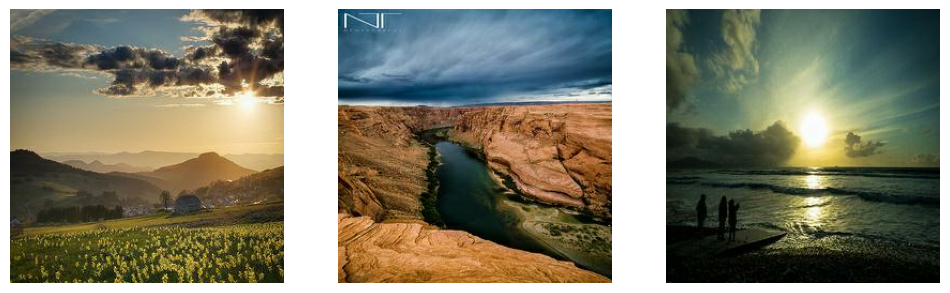

In [7]:
plt.figure(figsize=(12, 4))

image_batch, _ = next(iter(loaded_photo_files.batch(3)))
for i in range(3):
    img = to_uint8(to_01(image_batch[i]))
    plt.subplot(1,3,1+i)    
    plt.imshow(img)
    plt.axis('off')

plt.show()

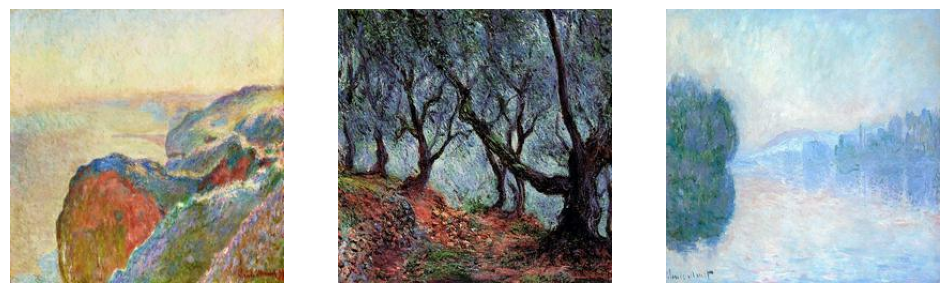

In [8]:
plt.figure(figsize=(12, 4))

image_batch, _ = next(iter(loaded_monet_files.batch(3)))
for i in range(3):
    img = to_uint8(to_01(image_batch[i]))
    plt.subplot(1,3,1+i)    
    plt.imshow(img)
    plt.axis('off')
    
plt.show()

In [9]:
from tensorflow.keras import layers, Sequential, Input

# --- 1. Gaussian Kernel Helper Function ---
@tf.function
def create_gaussian_kernel(kernel_size, sigma, channels):
    """Creates a 2D Gaussian kernel for depthwise convolution."""
    x_range = tf.range(-(kernel_size // 2), (kernel_size // 2) + 1, dtype=tf.float32)
    gaussian_1d = tf.exp(- (x_range ** 2) / (2.0 * (sigma ** 2)))
    gaussian_1d = gaussian_1d / tf.reduce_sum(gaussian_1d)
    gaussian_2d = tf.einsum('i,j->ij', gaussian_1d, gaussian_1d)
    gaussian_2d = tf.expand_dims(gaussian_2d, axis=-1)
    kernel = tf.expand_dims(gaussian_2d, axis=-1)
    kernel = tf.tile(kernel, [1, 1, channels, 1])
    return kernel

# --- 2. The Updated Keras Layer ---
class GaussianBlurLayer(layers.Layer):
    """
    A non-trainable Keras layer to apply Gaussian blur using tf.nn.depthwise_conv2d.
    This layer has NO external dependencies.
    """
    def __init__(self, kernel_size=11, sigma=3.0, **kwargs):
        # Set trainable to False to "ignore fit()"
        super().__init__(trainable=False, **kwargs)
        self.kernel_size = kernel_size
        self.sigma = sigma
        
        # Pre-build the kernel. We know the input has 3 channels.
        # We build it once and store it.
        self.kernel = create_gaussian_kernel(kernel_size, sigma, channels=3)

    def call(self, inputs):
        """
        This is what runs during model.predict(x)
        """
        # inputs shape is [batch, height, width, channels]
        # kernel shape is [height, width, in_channels, multiplier]
        
        # Ensure kernel is on the same device as inputs and has matching type
        kernel = tf.cast(self.kernel, inputs.dtype)
        
        # Apply the blur using a depthwise convolution
        # 'SAME' padding ensures the output image is 256x256
        blurred = tf.nn.depthwise_conv2d(
            inputs,
            kernel,
            strides=[1, 1, 1, 1],
            padding='SAME'
        )
        return blurred

In [10]:
blur_model = Sequential([
    Input(shape=(256, 256, 3)),
    GaussianBlurLayer(kernel_size=5, sigma=1.0)
])

blur_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_blur_layer             │ (None, 256, 256, 3)    │             0 │
│ (GaussianBlurLayer)             │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

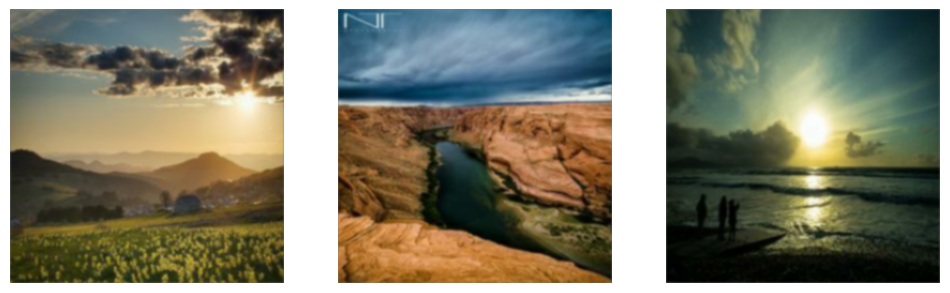

In [11]:
plt.figure(figsize=(12, 4))

image_batch, _ = next(iter(loaded_photo_files.batch(3)))
blurred_batch = blur_model(image_batch, training=False)
for i in range(3):
    img = to_uint8(to_01(blurred_batch[i]))
    plt.subplot(1,3,1+i)    
    plt.imshow(img)
    plt.axis('off')

plt.show()

In [12]:
from tqdm import tqdm

@tf.function
def save_image_from_tensor(image_tensor, output_path_tensor):
    img_uint8 = to_uint8(to_01(image_tensor))
    jpeg_string = tf.image.encode_jpeg(img_uint8, quality=95)
    tf.io.write_file(output_path_tensor, jpeg_string)

def save_processed_files(processor_model, loaded_photo_files, processed_dir):
    num_batches = (len(loaded_photo_files) + BATCH_SIZE - 1) // BATCH_SIZE

    for image_batch, path_batch in tqdm(loaded_photo_files.batch(BATCH_SIZE), total=num_batches):
        processed_batch = processor_model(image_batch, training=False)
        for i in range(image_batch.shape[0]):
            image_tensor = processed_batch[i]
            original_path_tensor = path_batch[i] # This is a string tensor
            filename = tf.strings.split(original_path_tensor, os.path.sep)[-1]
            output_path_tensor = tf.strings.join([processed_dir, filename], separator=os.path.sep)
            save_image_from_tensor(image_tensor, output_path_tensor)    

In [13]:
GENERATE_JUST_BLURRED = False  # Flip to True if needed

if GENERATE_JUST_BLURRED:
    blurred_dir = os.path.join(WORKING_DIR, 'blurred')
    os.makedirs(blurred_dir, exist_ok=True)

    save_processed_files(blur_model, loaded_photo_files, blurred_dir)

In [14]:
def random_crop(img):
    img = tf.image.random_crop(img, size=[IMG_HEIGHT, IMG_WIDTH, 3])
    return img


def random_jitter(img):
    # resizing to 286 x 286 x 3
    img = tf.image.resize(img, [286, 286])
    
    # randomly cropping to 256 x 256 x 3
    img = random_crop(img)

    # random mirroring
    img = tf.image.random_flip_left_right(img)
    return img


def preprocess_image_train(img, _):
    img = random_jitter(img)
    return img


training_photo_dataset = loaded_photo_files.cache().map(
    preprocess_image_train, num_parallel_calls=AUTOTUNE).shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

training_monet_dataset = loaded_monet_files.cache().map(
    preprocess_image_train, num_parallel_calls=AUTOTUNE).shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [15]:
!pip install -q git+https://github.com/tensorflow/examples.git

  Preparing metadata (setup.py) ... done


In [64]:
from tensorflow_examples.models.pix2pix import pix2pix

OUTPUT_CHANNELS = 3

generator_g = pix2pix.unet_generator(OUTPUT_CHANNELS, norm_type='instancenorm')
generator_f = pix2pix.unet_generator(OUTPUT_CHANNELS, norm_type='instancenorm')

discriminator_x = pix2pix.discriminator(norm_type='instancenorm', target=False)
discriminator_y = pix2pix.discriminator(norm_type='instancenorm', target=False)

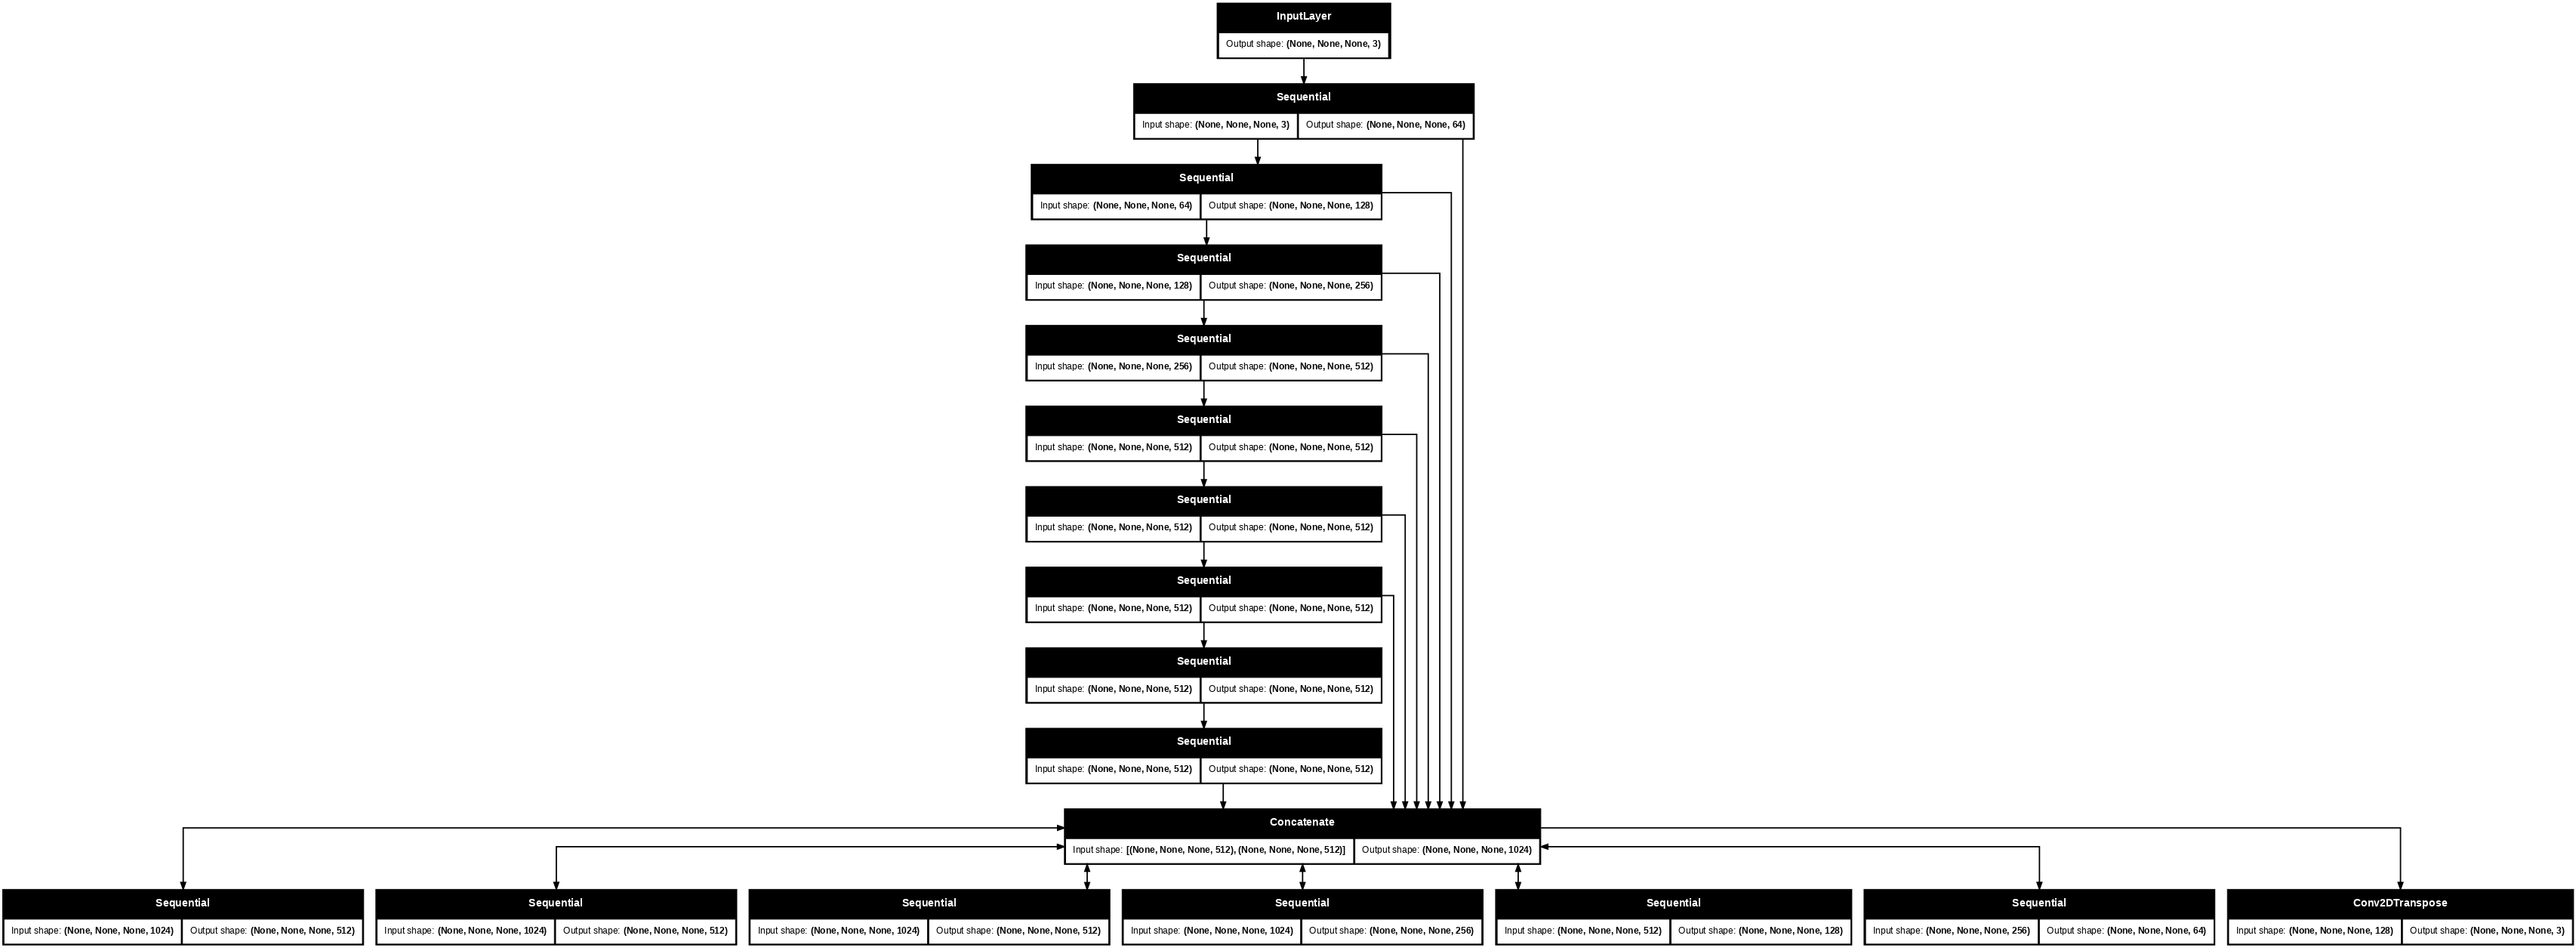

In [17]:
tf.keras.utils.plot_model(generator_f, show_shapes=True, dpi=64)

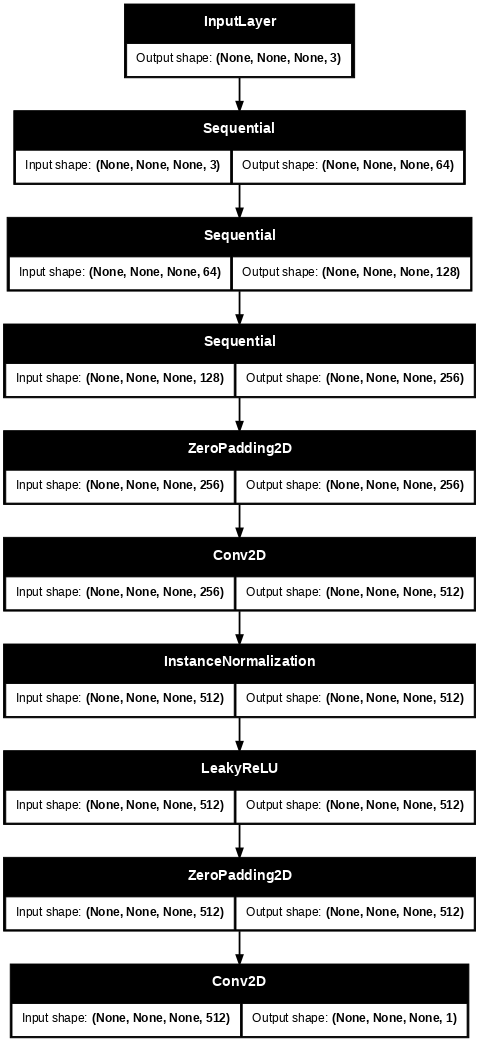

In [31]:
tf.keras.utils.plot_model(discriminator_x, show_shapes=True, dpi=64)

In [18]:
generator_g.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, None,      │      3,072 │ input_layer_1[0]… │
│ (Sequential)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, None,      │    131,328 │ sequential_1[0][… │
│ (Sequential)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, None,      │    524,800 │ sequential_2[0][… │
│ (Sequential)        │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, None,      │  2,098,176 │ sequential_3[0][… │
│ (Sequential)        │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, None,      │  4,195,328 │ sequential_4[0][… │
│ (Sequential)        │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, None,      │  4,195,328 │ sequential_5[0][… │
│ (Sequential)        │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, None,      │  4,195,328 │ sequential_6[0][… │
│ (Sequential)        │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, None,      │  4,195,328 │ sequential_7[0][… │
│ (Sequential)        │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_9        │ (None, None,      │  4,195,328 │ sequential_8[0][… │
│ (Sequential)        │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None,      │          0 │ sequential_9[0][… │
│ (Concatenate)       │ None, 128)        │            │ sequential_7[0][… │
│                     │                   │            │ sequential_10[0]… │
│                     │                   │            │ sequential_6[0][… │
│                     │                   │            │ sequential_11[0]… │
│                     │                   │            │ sequential_5[0][… │
│                     │                   │            │ sequential_12[0]… │
│                     │                   │            │ sequential_4[0][… │
│                     │                   │            │ sequential_13[0]… │
│                     │                   │            │ sequential_3[0][… │
│                     │                   │            │ sequential_14[0]… │
│                     │                   │            │ sequential_2[0][… │
│                     │                   │            │ sequential_15[0]… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_10       │ (None, None,      │  8,389,632 │ concatenate[0][0] │
│ (Sequential)        │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_11       │ (None, None,      │  8,389,632 │ concatenate[1][0

 Total params: 54,414,979 (207.58 MB)

 Trainable params: 54,414,979 (207.58 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
discriminator_x.summary()

Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_31 (Sequential)      │ (None, None, None, 64) │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_32 (Sequential)      │ (None, None, None,     │       131,328 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_33 (Sequential)      │ (None, None, None,     │       524,800 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, None, None,     │     2,097,152 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ instance_normalization_30       │ (None, None, None,     │         1,024 │
│ (InstanceNormalization)         │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_1                │ (None, None, None,     │             0 │
│ (ZeroPadding2D)                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, None, None, 1)  │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,765,569 (10.55 MB)

 Trainable params: 2,765,569 (10.55 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
LAMBDA = 10

loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real, generated):
    real_loss = loss_obj(tf.ones_like(real), real)
    generated_loss = loss_obj(tf.zeros_like(generated), generated)
    total_disc_loss = real_loss + generated_loss
    return total_disc_loss * 0.5

def generator_loss(generated):
    return loss_obj(tf.ones_like(generated), generated)

def calc_cycle_loss(real_image, cycled_image):
    loss1 = tf.reduce_mean(tf.abs(real_image - cycled_image))
    return LAMBDA * loss1

def identity_loss(real_image, same_image):
    loss = tf.reduce_mean(tf.abs(real_image - same_image))
    return LAMBDA * 0.5 * loss

In [21]:
class CycleGan(tf.keras.Model):
    def __init__(self, generator_g, generator_f, discriminator_x, discriminator_y):
        super(CycleGan, self).__init__()
        self.generator_g = generator_g
        self.generator_f = generator_f
        self.discriminator_x = discriminator_x
        self.discriminator_y = discriminator_y

        self.gen_g_loss_tracker = tf.keras.metrics.Mean(name="gen_g_loss")
        self.gen_f_loss_tracker = tf.keras.metrics.Mean(name="gen_f_loss")
        self.total_cycle_loss_tracker = tf.keras.metrics.Mean(name="total_cycle_loss")
        self.total_gen_g_loss_tracker = tf.keras.metrics.Mean(name="total_gen_g_loss")
        self.total_gen_f_loss_tracker = tf.keras.metrics.Mean(name="total_gen_f_loss")
        self.disc_x_loss_tracker = tf.keras.metrics.Mean(name="disc_x_loss")
        self.disc_y_loss_tracker = tf.keras.metrics.Mean(name="disc_y_loss")

    @property
    def metrics(self):        
        return [
            self.gen_g_loss_tracker,
            self.gen_f_loss_tracker,
            self.total_cycle_loss_tracker,
            self.total_gen_g_loss_tracker,
            self.total_gen_f_loss_tracker,
            self.disc_x_loss_tracker,
            self.disc_y_loss_tracker,
        ]

    def compile(self, generator_g_optimizer, generator_f_optimizer, discriminator_x_optimizer, discriminator_y_optimizer):
        super(CycleGan, self).compile()
        self.generator_g_optimizer = generator_g_optimizer
        self.generator_f_optimizer = generator_f_optimizer
        self.discriminator_x_optimizer = discriminator_x_optimizer
        self.discriminator_y_optimizer = discriminator_y_optimizer


    @tf.function
    def train_step(self, data):
        real_x, real_y = data

        with tf.GradientTape(persistent=True) as tape:
            # Generator G translates X -> Y
            # Generator F translates Y -> X.
            fake_y = self.generator_f(real_x, training=True)
            cycled_x = self.generator_g(fake_y, training=True)

            fake_x = self.generator_f(real_y, training=True)
            cycled_y = self.generator_g(fake_x, training=True)

            # same_x and same_y are used for identity loss.
            same_x = self.generator_f(real_x, training=True)
            same_y = self.generator_g(real_y, training=True)

            disc_real_x = self.discriminator_x(real_x, training=True)
            disc_real_y = self.discriminator_y(real_y, training=True)

            disc_fake_x = self.discriminator_x(fake_x, training=True)
            disc_fake_y = self.discriminator_y(fake_y, training=True)

            # calculate the loss
            gen_g_loss = generator_loss(disc_fake_y)
            gen_f_loss = generator_loss(disc_fake_x)

            total_cycle_loss = calc_cycle_loss(real_x, cycled_x) + calc_cycle_loss(real_y, cycled_y)

            # Total generator loss = adversarial loss + cycle loss
            total_gen_g_loss = gen_g_loss + total_cycle_loss + identity_loss(real_y, same_y)
            total_gen_f_loss = gen_f_loss + total_cycle_loss + identity_loss(real_x, same_x)

            disc_x_loss = discriminator_loss(disc_real_x, disc_fake_x)
            disc_y_loss = discriminator_loss(disc_real_y, disc_fake_y)

        # Track the metrics
        self.gen_g_loss_tracker.update_state(gen_g_loss)
        self.gen_f_loss_tracker.update_state(gen_f_loss)
        self.total_cycle_loss_tracker.update_state(total_cycle_loss)
        self.total_gen_g_loss_tracker.update_state(total_gen_g_loss)
        self.total_gen_f_loss_tracker.update_state(total_gen_f_loss)
        self.disc_x_loss_tracker.update_state(disc_x_loss)
        self.disc_y_loss_tracker.update_state(disc_y_loss)

        # Calculate the gradients for generator and discriminator
        generator_g_gradients = tape.gradient(total_gen_g_loss, generator_g.trainable_variables)
        generator_f_gradients = tape.gradient(total_gen_f_loss, generator_f.trainable_variables)

        discriminator_x_gradients = tape.gradient(disc_x_loss, discriminator_x.trainable_variables)
        discriminator_y_gradients = tape.gradient(disc_y_loss, discriminator_y.trainable_variables)

        # Apply the gradients to the optimizer
        self.generator_g_optimizer.apply_gradients(zip(generator_g_gradients,
                                                       generator_g.trainable_variables))
        self.generator_f_optimizer.apply_gradients(zip(generator_f_gradients,
                                                       generator_f.trainable_variables))
        self.discriminator_x_optimizer.apply_gradients(zip(discriminator_x_gradients,
                                                           discriminator_x.trainable_variables))
        self.discriminator_y_optimizer.apply_gradients(zip(discriminator_y_gradients,
                                                           discriminator_y.trainable_variables))


        return {m.name: m.result() for m in self.metrics}

In [63]:
generator_g_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
generator_f_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_x_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_y_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [46]:
cycle_gan_model = CycleGan(generator_g, generator_f, discriminator_x, discriminator_y)
cycle_gan_model.compile(generator_g_optimizer, generator_f_optimizer, discriminator_x_optimizer, discriminator_y_optimizer)

In [36]:
class ModelEpochEndCheckpoint(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if ((epoch + 1) % 5) == 0:
            epoch_dir = os.path.join(WORKING_DIR, f'model-epoch-{(epoch + 1):03}')
            os.makedirs(epoch_dir, exist_ok=True)
            generator_g.save_weights(os.path.join(epoch_dir, 'generator_g.weights.h5'))

save_generator_g_cb = ModelEpochEndCheckpoint()

In [ ]:
history = cycle_gan_model.fit(tf.data.Dataset.zip((training_photo_dataset, training_monet_dataset)), epochs=50, callbacks=[save_generator_g_cb])

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 286ms/step - disc_x_loss: 0.5969 - disc_y_loss: 0.1111 - gen_f_loss: 0.9619 - gen_g_loss: 4.9586 - total_cycle_loss: 1.3130 - total_gen_f_loss: 2.5957 - total_gen_g_loss: 6.5350
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 286ms/step - disc_x_loss: 0.6140 - disc_y_loss: 0.1032 - gen_f_loss: 0.9529 - gen_g_loss: 4.8078 - total_cycle_loss: 1.2016 - total_gen_f_loss: 2.4539 - total_gen_g_loss: 6.2543
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 286ms/step - disc_x_loss: 0.5866 - disc_y_loss: 0.0581 - gen_f_loss: 1.0261 - gen_g_loss: 5.3736 - total_cycle_loss: 1.2059 - total_gen_f_loss: 2.5281 - total_gen_g_loss: 6.8287
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 286ms/step - disc_x_loss: 0.5729 - disc_y_loss: 0.0877 - gen_f_loss: 1.0217 - gen_g_loss: 5.0669 - total_cycle_loss: 1.2100 - total_gen_f_loss: 2.5373 - total_gen_g_loss: 6.5196
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 293ms/step - disc_x_loss: 0.6005 - disc_y_loss: 0.1083 - gen_f_loss: 0.9780 - 

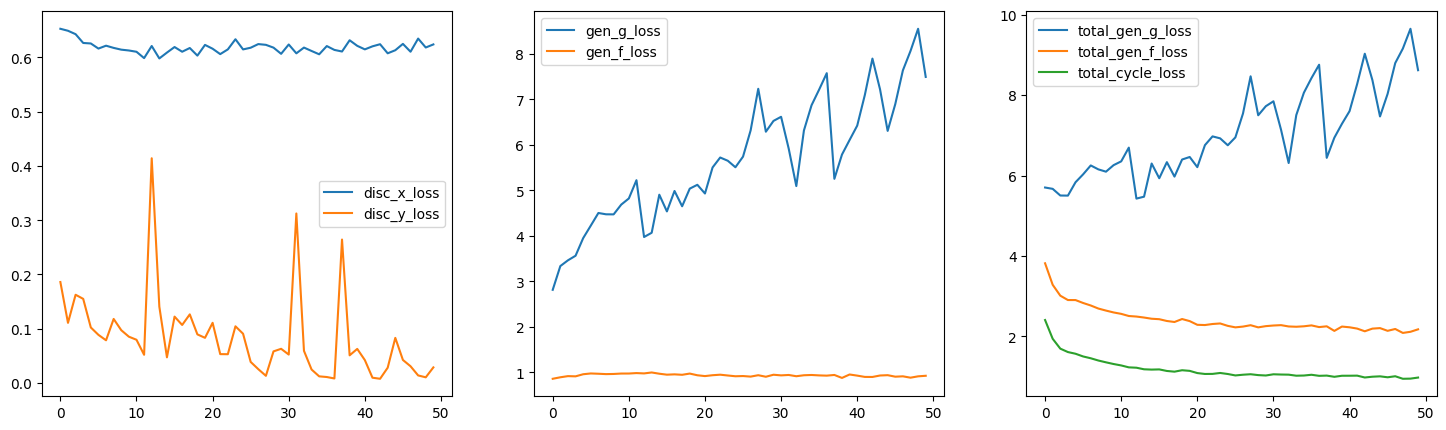

In [30]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

h = history.history

ax[0].plot(h['disc_x_loss'], label='disc_x_loss')
ax[0].plot(h['disc_y_loss'], label='disc_y_loss')
ax[0].legend()

ax[1].plot(h['gen_g_loss'], label='gen_g_loss')
ax[1].plot(h['gen_f_loss'], label='gen_f_loss')
ax[1].legend()

ax[2].plot(h['total_gen_g_loss'], label='total_gen_g_loss')
ax[2].plot(h['total_gen_f_loss'], label='total_gen_f_loss')
ax[2].plot(h['total_cycle_loss'], label='total_cycle_loss')
ax[2].legend()

plt.show()

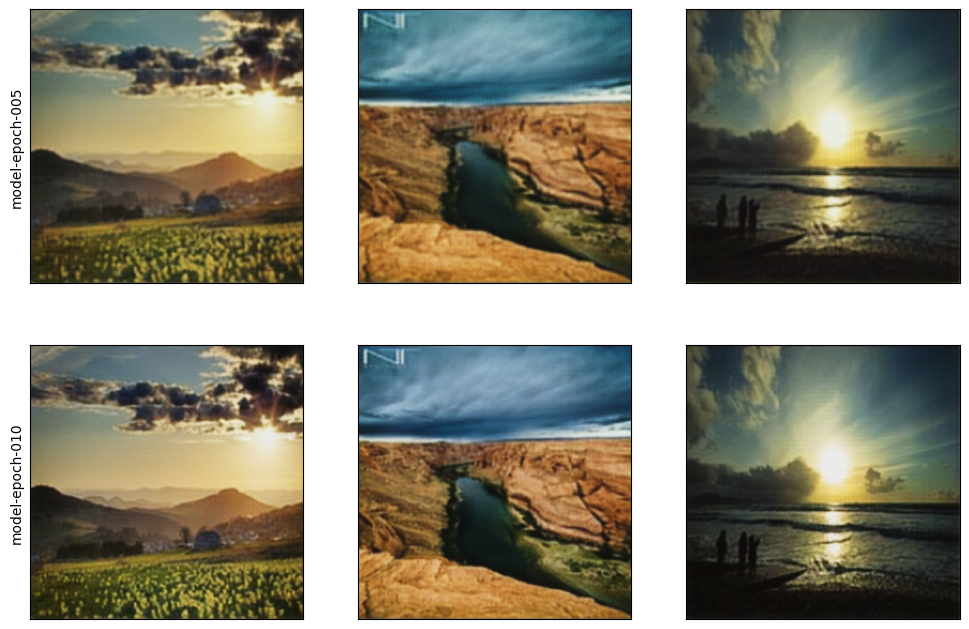

In [51]:
import glob
import re

image_batch, _ = next(iter(loaded_photo_files.batch(3)))

widcard = os.path.join(WORKING_DIR, 'model-epoch-*', 'generator_g.weights.h5')
model_weight_files = sorted(glob.glob(widcard))

n = len(model_weight_files)
fig, ax = plt.subplots(nrows=n, ncols=3, figsize=(12, 4*n))

for i, model_weight_file_name in enumerate(model_weight_files):
    model_dir = re.split(r'[\\/]', model_weight_file_name)[-2]

    generator_g.load_weights(model_weight_file_name)
    generated_batch = generator_g(image_batch, training=False)

    ax[i, 0].set_ylabel(model_dir)

    for j in range(3):
        img = to_uint8(to_01(generated_batch[j]))
        ax[i, j].imshow(img)
        ax[i, j].set_yticks([])
        ax[i, j].set_xticks([])


plt.show()

In [52]:
best_weights_epoch = 'model-epoch-010'
best_weights_file_name = os.path.join(WORKING_DIR, best_weights_epoch, 'generator_g.weights.h5')
generator_g.load_weights(best_weights_file_name)

In [53]:
post_generator_blur = Sequential([
    generator_g,
    GaussianBlurLayer(kernel_size=5, sigma=0.8),
])

post_generator_blur.summary()

Model: "sequential_145"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_136 (Functional)     │ (None, None, None, 3)  │    54,414,979 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_blur_layer_1           │ (None, None, None, 3)  │             0 │
│ (GaussianBlurLayer)             │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,414,979 (207.58 MB)

 Trainable params: 54,414,979 (207.58 MB)

 Non-trainable params: 0 (0.00 B)

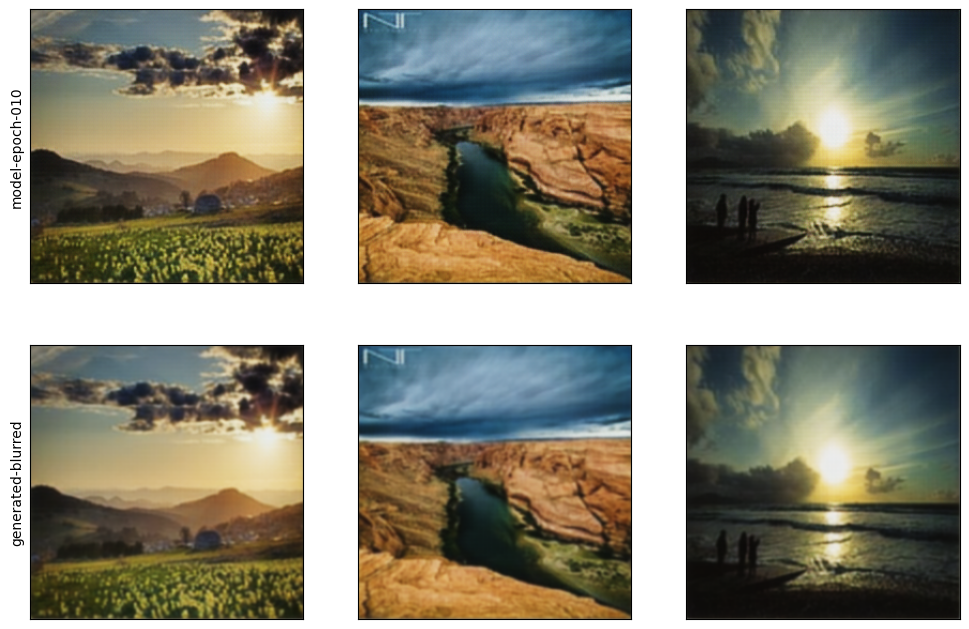

In [54]:
image_batch, _ = next(iter(loaded_photo_files.batch(3)))

generated_batch = generator_g(image_batch, training=False)
blurred_batch = post_generator_blur(image_batch, training=False)

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))

ax[0, 0].set_ylabel(best_weights_epoch)
ax[1, 0].set_ylabel('generated-blurred')

for i in range(3):
    img = to_uint8(to_01(generated_batch[i]))
    ax[0, i].imshow(img)
    ax[0, i].set_yticks([])
    ax[0, i].set_xticks([])

for i in range(3):
    img = to_uint8(to_01(blurred_batch[i]))
    ax[1, i].imshow(img)
    ax[1, i].set_yticks([])
    ax[1, i].set_xticks([])

plt.show()

In [55]:
blurred_dir = os.path.join(WORKING_DIR, 'generated-blurred')
os.makedirs(blurred_dir, exist_ok=True)

save_processed_files(post_generator_blur, loaded_photo_files, blurred_dir)

100%|██████████| 1760/1760 [02:26<00:00, 12.05it/s]


In [57]:
!zip -jq images.zip generated-blurred/*.jpg